<a href="https://colab.research.google.com/github/juanpajedrez/pytorch_learning/blob/main/09_pytorch_model_deploy_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 09. PyTorch Model Deployment

What is model deployment?

Machine learning model deployment is the act of making your machine learning model (s) available to someone or something else.

## Resources:
* Book version of notebook: https://www.learnpytorch.io/09_pytorch_model_deployment/
* Slides: https://github.com/mrdbourke/pytorch-deep-learning/blob/main/slides/09_pytorch_model_deployment.pdf


## 0. Get setup

In [ ]:
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu113
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")

[INFO] torch/torchvision versions not as required, installing nightly versions.
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu113
torch version: 2.11.0+cu130
torchvision version: 0.26.0+cu130


In [ ]:
import torch
import torchvision
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
!nvidia-smi

Thu Apr 23 14:51:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   47C    P8             17W /   72W |       3MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Getting Data

The dataset we're going to use for deploying a FoodVision Mini model is ...

Pizza, steak, sushi, 20% dataset (pizza, steak, sushi classes from Food101, random 20% of samples).


Link: https://www.learnpytorch.io/09_pytorch_model_deployment/#0-getting-setup

In [ ]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !mv pytorch-deep-learning/helper_functions.py . # get the helper_functions.py script
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves

[INFO] Couldn't find torchinfo... installing it.
[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.
Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4410, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 4410 (delta 5), reused 2 (delta 2), pack-reused 4400 (from 2)
Receiving objects: 100% (4410/4410), 764.18 MiB | 18.92 MiB/s, done.
Resolving deltas: 100% (2661/2661), done.
Updating files: 100% (248/248), done.


In [ ]:
# Download pizza, steak, sushi images from GitHub
data_20_percent_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
                                     destination="pizza_steak_sushi_20_percent")

data_20_percent_path

[INFO] Did not find data/pizza_steak_sushi_20_percent directory, creating one...
[INFO] Downloading pizza_steak_sushi_20_percent.zip from https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip...
[INFO] Unzipping pizza_steak_sushi_20_percent.zip data...


PosixPath('data/pizza_steak_sushi_20_percent')

In [ ]:
# Steup trianing and test paths
train_dir = data_20_percent_path / "train"
test_dir = data_20_percent_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi_20_percent/train'),
 PosixPath('data/pizza_steak_sushi_20_percent/test'))

## 2. FoodVision Mini model deployment experiment outline

### 3. Questions
1. What is my most ideal machine learning model deployment scenario?
2. Where is my model going to go?
3. How is my model going to function?

**FoodVision Mini Ideal use case:** A model that performs well and fast.

* Performs well: 95%+ accuracy
* Fast: as close to human eye can see. (30 and 60 frames per second).
  * Latency = time for prediction to take place

To try and achiev ethese goals, we're going to build two model experiments:

1. EffnetB2 feature extractor (just like in 07. PyTorcg Experiment Tracking)
2. ViT feature extractor (just like in 08. PyTorch Paper Replicating).

## 3. Creating an EffNetB2 feature extractor
Feature extractor = a term for a transfer lerning model that has its base layers frozone and output layers (or head layers) customized to a certain problem.

EffnetB2 pretrained model in PyTorch -
https://docs.pytorch.org/vision/main/models/generated/torchvision.models.efficientnet_b2.html#torchvision.models.EfficientNet_B2_Weights

In [ ]:
import torchvision
torchvision.__version__
# 1. Setup pretrained EffNeetB2 Weights
effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT # DEFAULT is equivalent to saying best available

# 2. Get EffNetB2 transforms
effnetb2_transforms = effnetb2_weights.transforms()

# 3. Setup pretrained model instance
effnetb2 = torchvision.models.efficientnet_b2(weights=effnetb2_weights).to(device) # Could also use "DEFAULT" for weights parameter

# 4 Freeze the base layers in the model (this will stop all layers from trianing)
for param in effnetb2.parameters():
  param.requires_grad = False

In [ ]:
# from torchinfo import summary
summary(model = effnetb2,
        input_size=(1, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

In [ ]:
# Set seeds for reproducibility
set_seeds()
effnetb2.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(in_features = 1408, out_features=3, bias=True))

### 3.1 Creating a function to make an EffNetB2 feature extractor

In [ ]:
def create_effnetb2_model(num_classes:int = 3, # default output classes =3 (pizza, steak, sushi)
                          seed:int = 42):
  # 1, 2, 3 Create EffNetb2 pretrained weights, transforms, and model
  weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
  transforms = weights.transforms()
  model = torchvision.models.efficientnet_b2(weights=weights)

  # 4. Freeze all layers
  for param in model.parameters():
    param.requires_grad = False

  # 5.Change classifier head with random seed for reproducibility
  torch.manual_seed(seed)
  model.classifier = nn.Sequential(
      nn.Dropout(p = 0.3, inplace=True),
      nn.Linear(in_features=1408, out_features=num_classes)
  )

  return model, transforms

In [ ]:
effnetb2, effnetb2_transforms = create_effnetb2_model(
  num_classes=3,
  seed=42)

In [ ]:
effnetb2_transforms

ImageClassification(
    crop_size=[288]
    resize_size=[288]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

### 3.2 Creating DataLoader for EffNetb2

In [ ]:
# Setup Dataloadeers
from going_modular.going_modular import data_setup

train_dataloader_effnetb2, test_dataloader_effnetb2, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                                                  test_dir = test_dir,
                                                                                                  transform = effnetb2_transforms,
                                                                                                  batch_size = 32,
                                                                                                  )

In [ ]:
len(train_dataloader_effnetb2), len(test_dataloader_effnetb2), class_names

(15, 5, ['pizza', 'steak', 'sushi'])

### 3.3 Training EffNetB2 feature extractor

In [ ]:
from going_modular.going_modular import engine

# Loss function
loss_fn = torch.nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(
  params=effnetb2.parameters(),
  lr=1e-3)

# Training function (engine.py)
set_seeds()
effnetb2_results = engine.train(model=effnetb2,
                                train_dataloader=train_dataloader_effnetb2,
                                test_dataloader=test_dataloader_effnetb2,
                                optimizer=optimizer,
                                loss_fn=loss_fn,
                                epochs=10,
                                device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9843 | train_acc: 0.5667 | test_loss: 0.7410 | test_acc: 0.9347
Epoch: 2 | train_loss: 0.7171 | train_acc: 0.8396 | test_loss: 0.5877 | test_acc: 0.9409
Epoch: 3 | train_loss: 0.5878 | train_acc: 0.8938 | test_loss: 0.4901 | test_acc: 0.9563
Epoch: 4 | train_loss: 0.4481 | train_acc: 0.9125 | test_loss: 0.4350 | test_acc: 0.9409
Epoch: 5 | train_loss: 0.4302 | train_acc: 0.9062 | test_loss: 0.3921 | test_acc: 0.9443
Epoch: 6 | train_loss: 0.4400 | train_acc: 0.8875 | test_loss: 0.3523 | test_acc: 0.9597
Epoch: 7 | train_loss: 0.4253 | train_acc: 0.8792 | test_loss: 0.3267 | test_acc: 0.9563
Epoch: 8 | train_loss: 0.3900 | train_acc: 0.8979 | test_loss: 0.3462 | test_acc: 0.9352
Epoch: 9 | train_loss: 0.3769 | train_acc: 0.8771 | test_loss: 0.3130 | test_acc: 0.9131
Epoch: 10 | train_loss: 0.3769 | train_acc: 0.8625 | test_loss: 0.2814 | test_acc: 0.9688


### 3.4 Inspecting EffNetB2 loss curves

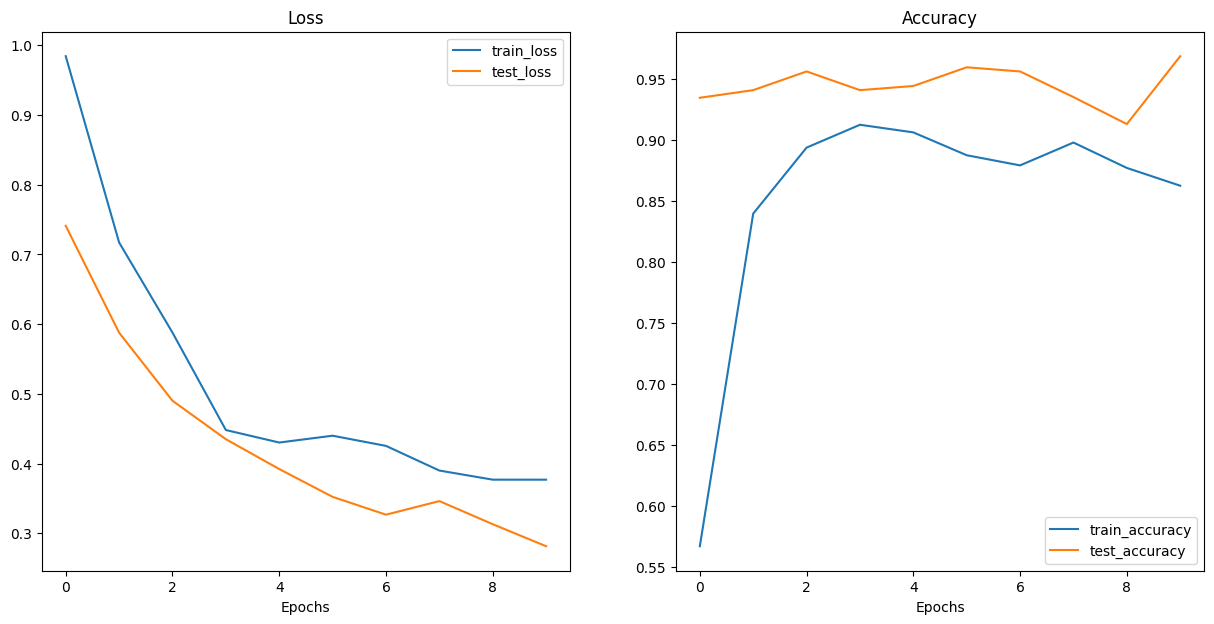

In [ ]:
from helper_functions import plot_loss_curves
plot_loss_curves(effnetb2_results)

See here for what an ideal loss curve should look like: https://www.learnpytorch.io/04_pytorch_custom_datasets/#8-what-should-an-ideal-loss-curve-look-like

### 3.5 Saving EffNetB2 feature extractor

In [ ]:
from going_modular.going_modular import utils

# Save the model
utils.save_model(model = effnetb2,
                 target_dir = "models",
                 model_name = "09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth")

[INFO] Saving model to: models/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth


### 3.6 Inspecting size of our EffNetB2 feature extractor

Why would it be important to consider the size of a saved model?

If we're deploying our model to be used on a mobile app/website, there may be limit compute resources.

So if our model file is too large, we may not be able to store/run it on our target device.

In [ ]:
from pathlib import Path

# Get the model size in bytes and convert to megabytes
pretrained_effnetb2_model_size = Path("/content/models/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth").stat().st_size / (1024 * 1024)
print(f"Pretrained EffNetB2 feature extractor model size: {pretrained_effnetb2_model_size:.2f}")

Pretrained EffNetB2 feature extractor model size: 29.86


### 3.7 Collecting EffNetB2 feature extractor stats

In [ ]:
# Count number of parameters in EffNetB2
effnetb2_total_params = sum(torch.numel(param) for param in effnetb2.parameters())
effnetb2_total_params

7705221

In [ ]:
# Create a dictionarty with EffNetB2 statistics
effnetb2_stats = {"test_loss": effnetb2_results["test_loss"][-1],
                  "test_acc": effnetb2_results["test_acc"][-1],
                  "number of parameters": effnetb2_total_params,
                  "model_size (MB)": pretrained_effnetb2_model_size}
effnetb2_stats

{'test_loss': 0.2814371705055237,
 'test_acc': 0.96875,
 'number of parameters': 7705221,
 'model_size (MB)': 29.86450481414795}

### 4. Creating a ViT feature extractor
We're up to our second modelling experiment, repating the steps for EffNetB2 but this time with a ViT feature extractor, see here for ideas:
https://www.learnpytorch.io/08_pytorch_paper_replicating/#10-using-a-pretrained-vit-from-on-the-same-dataset

In [ ]:
# Check out the headers layer
vit = torchvision.models.vit_b_16()
vit.heads

Sequential(
  (head): Linear(in_features=768, out_features=1000, bias=True)
)

In [ ]:
# from torchinfo import summary
summary(model = vit,
        input_size=(1, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [1, 3, 224, 224]     [1, 1000]            768                  True
├─Conv2d (conv_proj)                                         [1, 3, 224, 224]     [1, 768, 14, 14]     590,592              True
├─Encoder (encoder)                                          [1, 197, 768]        [1, 197, 768]        151,296              True
│    └─Dropout (dropout)                                     [1, 197, 768]        [1, 197, 768]        --                   --
│    └─Sequential (layers)                                   [1, 197, 768]        [1, 197, 768]        --                   True
│    │    └─EncoderBlock (encoder_layer_0)                   [1, 197, 768]        [1, 197, 768]        7,087,872            True
│    │    └─EncoderBlock (encoder_layer_1)                   [1, 197, 768]        [1, 197, 768

In [ ]:
def create_vit_model(num_classes:int = 3,
                     seed:int = 42):
  # Create a ViT_B_16 pretrained weights, transforms and model
  weights = torchvision.models.ViT_B_16_Weights.DEFAULT
  transforms = weights.transforms()
  model = torchvision.models.vit_b_16(weights=weights)

  # Freeze all of the base layers
  for param in model.parameters():
    param.requires_grad = False

  # Change classifier head to suit our needs
  torch.manual_seed(seed)
  model.heads = nn.Sequential(
   nn.Linear(in_features=768, out_features=num_classes)
  )

  return model, transforms

In [ ]:
vit, vit_transforms = create_vit_model()
vit_transforms

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 216MB/s]


ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [ ]:
from torchinfo import summary
summary(model = vit,
        input_size=(1, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [1, 3, 224, 224]     [1, 3]               768                  Partial
├─Conv2d (conv_proj)                                         [1, 3, 224, 224]     [1, 768, 14, 14]     (590,592)            False
├─Encoder (encoder)                                          [1, 197, 768]        [1, 197, 768]        151,296              False
│    └─Dropout (dropout)                                     [1, 197, 768]        [1, 197, 768]        --                   --
│    └─Sequential (layers)                                   [1, 197, 768]        [1, 197, 768]        --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [1, 197, 768]        [1, 197, 768]        (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [1, 197, 768]        [1, 1

### 4.1 Create DataLoaders for Vit feature extractor

In [ ]:
from going_modular.going_modular import data_setup
train_dataloader_vit, test_dataloader_vit, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                                       test_dir=test_dir,
                                                                                       transform = vit_transforms,
                                                                                       batch_size = 32)

In [ ]:
len(train_dataloader_vit), len(test_dataloader_vit), class_names

(15, 5, ['pizza', 'steak', 'sushi'])

### 4.2 Training ViT feature extractor

We're up to model experiment number two: a ViT feature extractor.

In [ ]:
from going_modular.going_modular import engine

# Setup optimizer
optimizer = torch.optim.Adam(params=vit.parameters(), lr=1e-3)

# Setup loss function
loss_fn = torch.nn.CrossEntropyLoss()

# Train ViT feature extractor with seeds set for reproducibility
set_seeds()
vit_results = engine.train(model=vit,
                           train_dataloader = train_dataloader_vit,
                           test_dataloader = test_dataloader_vit,
                           epochs = 10,
                           optimizer = optimizer,
                           loss_fn = loss_fn,
                           device = device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.7020 | train_acc: 0.7521 | test_loss: 0.2714 | test_acc: 0.9381
Epoch: 2 | train_loss: 0.2532 | train_acc: 0.9062 | test_loss: 0.1672 | test_acc: 0.9602
Epoch: 3 | train_loss: 0.1764 | train_acc: 0.9542 | test_loss: 0.1273 | test_acc: 0.9693
Epoch: 4 | train_loss: 0.1276 | train_acc: 0.9625 | test_loss: 0.1074 | test_acc: 0.9722
Epoch: 5 | train_loss: 0.1159 | train_acc: 0.9646 | test_loss: 0.0953 | test_acc: 0.9784
Epoch: 6 | train_loss: 0.1273 | train_acc: 0.9375 | test_loss: 0.0832 | test_acc: 0.9722
Epoch: 7 | train_loss: 0.0897 | train_acc: 0.9771 | test_loss: 0.0845 | test_acc: 0.9784
Epoch: 8 | train_loss: 0.0919 | train_acc: 0.9812 | test_loss: 0.0764 | test_acc: 0.9722
Epoch: 9 | train_loss: 0.0922 | train_acc: 0.9792 | test_loss: 0.0734 | test_acc: 0.9784
Epoch: 10 | train_loss: 0.0658 | train_acc: 0.9833 | test_loss: 0.0644 | test_acc: 0.9847


### 4.3 Plot loss curves of ViT feature extractor

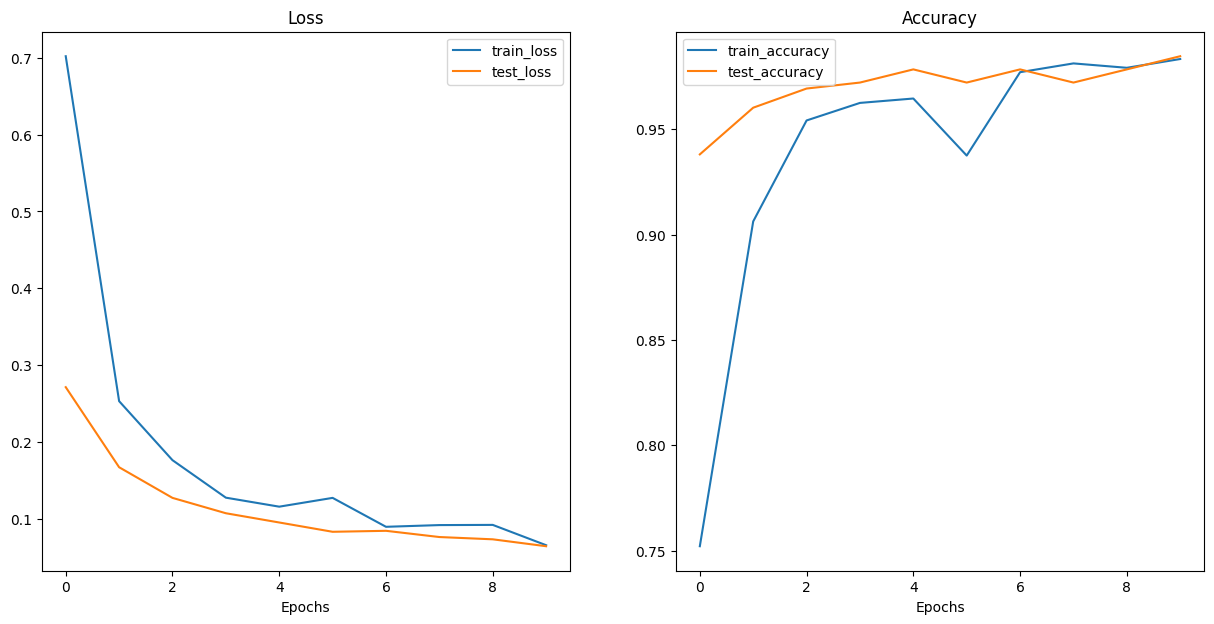

In [ ]:
from helper_functions import plot_loss_curves
plot_loss_curves(vit_results)

For more on what an ideal losss curves should look like, take a look here: https://www.learnpytorch.io/04_pytorch_custom_datasets/#82-how-to-deal-with-underfitting

### 4.4 Saving ViT feature extractor

In [ ]:
# Save model
from going_modular.going_modular import utils

utils.save_model(model=vit,
                 target_dir = "models",
                 model_name = "09_pretrained_vit_feature_extractor_pizza_steak_sushi_20_percent.pth")

[INFO] Saving model to: models/09_pretrained_vit_feature_extractor_pizza_steak_sushi_20_percent.pth


### 4.5 Checking the size of ViT feature extractor

In [ ]:
from pathlib import Path

# Get the model size in bytes then convert to megabytes
pretrained_vit_model_size = Path("/content/models/09_pretrained_vit_feature_extractor_pizza_steak_sushi_20_percent.pth").stat().st_size / (1024 * 1024)
print(f"Pretrained Vit feature extractor size: {pretrained_vit_model_size:.3f}")

Pretrained Vit feature extractor size: 327.372


In [ ]:
pretrained_vit_model_size

327.3715181350708

### 4.6 Collecting ViT feature extractor stats

In [ ]:
# Count number of parameters in ViT
vit_total_params = sum([torch.numel(param) for param in vit.parameters()])
vit_total_params

85800963

In [ ]:
# Create ViT statistics dictionary
vit_stats = {"test_loss": vit_results["test_loss"][-1],
             "test_acc": vit_results["test_acc"][-1],
             "number of parameters": vit_total_params,
             "model_size (MB)": pretrained_vit_model_size}
vit_stats

{'test_loss': 0.06443869592621923,
 'test_acc': 0.984659090909091,
 'number of parameters': 85800963,
 'model_size (MB)': 327.3715181350708}

## 5. Making predictions with our trained models and timing

Our goal:
1. Performs well (95% + test accuracy).
2. Fast (30 + FPS).

To test criteria two:
1. Loop through test images.
2. Time how long each model takes to make a prediction on the image.

Let's work towards making a function called `pred_and_store()` to do so.

First we'll need a lust of test image paths.

In [ ]:
from pathlib import Path

# Get all test data paths
test_data_paths = list(Path(test_dir).glob("*/*.jpg"))
test_data_paths[:5]

[PosixPath('data/pizza_steak_sushi_20_percent/test/sushi/124279.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/sushi/1600999.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/sushi/2394442.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/sushi/1063878.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/sushi/2416569.jpg')]

### 5.1 Creating a function to make across the test dataset

Steps to create `pred_and_store()`:

1. Create a function that takes a list of paths and a trained PyTorch and a series of transforms a list of target class names and target device.
2. Create an empty list (can return a full list of all predictions later).
3. Loop thorugh the target input paths (the rest of the steps will take place inside the loop).
4. Create an empty dictionary for each sample (prediction statistics will go in here).
5. Get the sample path and ground truth class from the filepath.
6. Start the prediction timer.
7. Open the image using `PIL.Image.open(path)`.
8. Transform the image to be usable with a given model.
9. Prepare the model for inference by senidng to the target device and turning on `eval()` mode.
10. Turn on `torch.inference_mode()`and pass the target transformed image to the model and perform forward pass + calculate pred prob + pred class
11. Add the pred prob + pred class to empty dictionary from step 4
12. End the prediction timer started in step 6 and add the time to the prediction dictionary.
13. See if the predicted class matches the ground truth class.
14. Append the updated prediction dicitonary to the empty list of predictions we created in step 2.
15. Return the list of prediction dictionaries.

In [ ]:
from IPython.utils.path import ensure_dir_exists
import pathlib
import torch

from PIL import Image
from timeit import default_timer as timer
from tqdm import tqdm
from typing import List, Dict

# 1 Create a function that takes a list of paths and a trained PyTorch and a series of transforms a list of target class names and target device.
def pred_and_store(paths: List[pathlib.Path],
                   model:torch.nn.Module,
                   transform:torchvision.transforms,
                   class_names:List[str],
                   device: str = "cuda" if torch.cuda.is_available() else "cpu") -> List[Dict]:

  # 2 Create an empty list (can return a full list of all predictions later).
  pred_list = []

  # 3. Loop through the target input paths (the rest of the steps will take place inside the loop).
  for path in tqdm(paths, desc = "Iterating across images paths...", total=len(paths)):

    # 4. Create an empty dictionary for each sample (prediction statistics will go in here)
    pred_dict = {}

    # 5. Get the sample path and ground truth class from the filepath
    pred_dict["image_path"] = path
    class_name = path.parent.stem
    pred_dict["class_name"] = class_name

    # 6. Start the prediction timer.
    start_time = timer()

    # 7. Open the image using `PIL.Image.open(path)`
    image = Image.open(path)

    # 8. Transform the image to be usable by the given model
    transformed_image = transform(image).unsqueeze(0).to(device) # -> Add a batch dimension for 1*C*H*W

    # 9. Prepare the model for inference by senidng to the target device and turning on eval() mode.
    model = model.to(device)
    model.eval()

    # 10. Turn on torch.inference_mode()and pass the target transformed image to the model and perform forward pass + calculate pred prob + pred class
    with torch.inference_mode():
      pred_logit = model(transformed_image)
      pred_prob = torch.softmax(pred_logit, dim=1) # Turn logits to prediction probabilities
      pred_label = torch.argmax(pred_prob, dim = 1) # Turn probabilities into predicted label
      pred_class = class_names[pred_label.cpu().item()] # Use pred_label.item(), into CPU since hardcode prediction into CPU.

      # 11. Add the pred prob + pred class to empty dictionary from step 4
      pred_dict["pred_prob"] = round(pred_prob.unsqueeze(0).max().cpu().item(), 4)
      pred_dict["pred_class"] = pred_class

      # 12. End the prediction timer started in step
      end_time = timer()
      pred_dict["time_for_pred"] = round(end_time - start_time, 4)

    #13. See if the predicted class mathces the ground truth class.
    pred_dict["correct"] = class_name == pred_class

    #14 Append the updated prediction dicitonary to the empty list of predictions we created in step 2.
    pred_list.append(pred_dict)

  #15. Return the list of prediction dictionaries.
  return pred_list

### 5.2 Making and timing predictions with EffNetB2

Let's test our `pred_and_store()` function.

Two things to note:
1. Device - We're going to hardcpde our predictions to happen to CPU (because you won't always be sure of having a GPU when you deploy a model).
2. Transforms - we want to make sure each of the models are predicting on images that have been prepared with the appropiate transforms (e.g EffNetB2 with `effnetb2_transforms`).

In [ ]:
# Make predictions test dataset with EffNetB2
effnetb2_test_pred_dicts = pred_and_store(
    paths=test_data_paths,
    model=effnetb2,
    transform=effnetb2_transforms,
    class_names=class_names,
    device="cpu") # Hardcode predictions to happen in CPU

Iterating across images paths...: 100%|██████████| 150/150 [00:07<00:00, 19.44it/s]


In [ ]:
effnetb2_test_pred_dicts

[{'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/sushi/124279.jpg'),
  'class_name': 'sushi',
  'pred_prob': 0.5642,
  'pred_class': 'sushi',
  'time_for_pred': 0.216,
  'correct': True},
 {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/sushi/1600999.jpg'),
  'class_name': 'sushi',
  'pred_prob': 0.9549,
  'pred_class': 'sushi',
  'time_for_pred': 0.0495,
  'correct': True},
 {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/sushi/2394442.jpg'),
  'class_name': 'sushi',
  'pred_prob': 0.8396,
  'pred_class': 'sushi',
  'time_for_pred': 0.047,
  'correct': True},
 {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/sushi/1063878.jpg'),
  'class_name': 'sushi',
  'pred_prob': 0.9611,
  'pred_class': 'sushi',
  'time_for_pred': 0.0463,
  'correct': True},
 {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/sushi/2416569.jpg'),
  'class_name': 'sushi',
  'pred_prob': 0.9516,
  'pred_class': 'sushi',
  'time_for_pre

In [ ]:
# Turn the test_pred_dicts into a DataFrame
import pandas as pd
effnetb2_test_pred_df = pd.DataFrame(effnetb2_test_pred_dicts)
effnetb2_test_pred_df

,image_path,class_name,pred_prob,pred_class,time_for_pred,correct
0,data/pizza_steak_sushi_20_percent/test/sushi/1...,sushi,0.5642,sushi,0.2160,True
1,data/pizza_steak_sushi_20_percent/test/sushi/1...,sushi,0.9549,sushi,0.0495,True
2,data/pizza_steak_sushi_20_percent/test/sushi/2...,sushi,0.8396,sushi,0.0470,True
3,data/pizza_steak_sushi_20_percent/test/sushi/1...,sushi,0.9611,sushi,0.0463,True
4,data/pizza_steak_sushi_20_percent/test/sushi/2...,sushi,0.9516,sushi,0.0502,True
...,...,...,...,...,...,...
145,data/pizza_steak_sushi_20_percent/test/pizza/2...,pizza,0.9704,pizza,0.0468,True
146,data/pizza_steak_sushi_20_percent/test/pizza/9...,pizza,0.9188,pizza,0.0471,True
147,data/pizza_steak_sushi_20_percent/test/pizza/7...,pizza,0.7546,pizza,0.0469,True
148,data/pizza_steak_sushi_20_percent/test/pizza/3...,pizza,0.5587,pizza,0.0469,True


In [ ]:
# Check the numer of correct predictions
effnetb2_test_pred_df.correct.value_counts()

,count
correct,
True,145
False,5


In [ ]:
# Find the average time per predictions
effnetb2_average_time_per_pred = round(effnetb2_test_pred_df.time_for_pred.mean(), 4)
effnetb2_average_time_per_pred

np.float64(0.0511)

In [ ]:
effnetb2_stats["time_per_pred"] = effnetb2_average_time_per_pred
effnetb2_stats

{'test_loss': 0.2814371705055237,
 'test_acc': 0.96875,
 'number of parameters': 7705221,
 'model_size (MB)': 29.86450481414795,
 'time_per_pred': np.float64(0.0511)}

**Note:** Prediction times will vary (much like training times) depending on the hardware you are using. So genreally the faster (e.g GPU or CPU) hardware, the faster the inference is.

### 5.3 Making and timing predictions with ViT


In [ ]:
# Make list of prediction dictionaries with ViT feature extractor model on test images
vit_test_pred_dicts = pred_and_store(paths=test_data_paths,
                                     model=vit,
                                     transform=vit_transforms,
                                     class_names=class_names,
                                     device = "cpu")

Iterating across images paths...: 100%|██████████| 150/150 [00:14<00:00, 10.05it/s]


In [ ]:
# Turn vit_test_preds
import pandas as pd
vit_test_pred_df = pd.DataFrame(vit_test_pred_dicts)
vit_test_pred_df.head()

,image_path,class_name,pred_prob,pred_class,time_for_pred,correct
0,data/pizza_steak_sushi_20_percent/test/sushi/1...,sushi,0.8880,sushi,0.2533,True
1,data/pizza_steak_sushi_20_percent/test/sushi/1...,sushi,0.9945,sushi,0.0892,True
2,data/pizza_steak_sushi_20_percent/test/sushi/2...,sushi,0.9632,sushi,0.0895,True
3,data/pizza_steak_sushi_20_percent/test/sushi/1...,sushi,0.9660,sushi,0.1034,True
4,data/pizza_steak_sushi_20_percent/test/sushi/2...,sushi,0.9903,sushi,0.0893,True


In [ ]:
vit_test_pred_df.correct.value_counts()

,count
correct,
True,148
False,2


In [ ]:
vit_average_time_per_pred = round(vit_test_pred_df.time_for_pred.mean(), 4)
vit_average_time_per_pred

np.float64(0.0989)

In [ ]:
vit_stats["time_per_pred"] = vit_average_time_per_pred
vit_stats

{'test_loss': 0.06443869592621923,
 'test_acc': 0.984659090909091,
 'number of parameters': 85800963,
 'model_size (MB)': 327.3715181350708,
 'time_per_pred': np.float64(0.0989)}

## 6. Comparing model results, prediction times, and size

In [ ]:
# Turn stat dictionaries into DataFrame
df = pd.DataFrame([effnetb2_stats, vit_stats])

# Add column for model names
df["model"] = ["EffNetB2", "ViT"]

# Convert accuracy to percentages
df["test_acc"] = round(df["test_acc"] * 100, 2)
df

,test_loss,test_acc,number of parameters,model_size (MB),time_per_pred,model
0,0.281437,96.88,7705221,29.864505,0.0511,EffNetB2
1,0.064439,98.47,85800963,327.371518,0.0989,ViT


Which model is better?
* `test_loss` (lower is better) -  ViT
* `test_acc` (higher is better) - ViT
* `number_of_parameters` (generally lower is better) - if a model has more parameters, it generally takes longer to compute,
  * Sometimes models with higher parameters can still perform fast.
* `model_size (MB)` - EffNetB2 (four our use case of deploying to a mobile device, generally lower is better)
* `time_per_pred_cpu` (lower is better, will be highly dependent on the hardware you're running on) - EffNetB2

Both models, with 30 FPS, hertz, which is indeed 0.0333ms, both the EffNetB2 and the ViT (BARELY) run in that way with G4 GPUs.

In [ ]:
# Comprae ViT to EffNetB2 across different characteristics
pd.DataFrame(data = df.set_index("model").loc["ViT"]/df.set_index("model").loc["EffNetB2"],
             columns = ["ViT to EffNetB2 rations"]).T

,test_loss,test_acc,number of parameters,model_size (MB),time_per_pred
ViT to EffNetB2 rations,0.228963,1.016412,11.135432,10.961893,1.935421


### 6.1 Visualizing the speed vs performance tradeoff

So we've compared our EffNetB2 and ViT feature extractor models, now let's visualize the comparison with a speed vs. performance plot.

We can do so with `matplotlib`:
1. Create a scatter plot from the comparison `DataFrame` to compare EffNetB2 and ViT across test accuracy and prediction time.
2. Add titles and labels to make our plot look nice.
3. Annotate the samples on the scatter plot so we know what's going on.
4. Create a legend based on the model sizes (`model_size (MB)`).

In [ ]:
df.head()

,test_loss,test_acc,number of parameters,model_size (MB),time_per_pred,model
0,0.281437,96.88,7705221,29.864505,0.0511,EffNetB2
1,0.064439,98.47,85800963,327.371518,0.0989,ViT


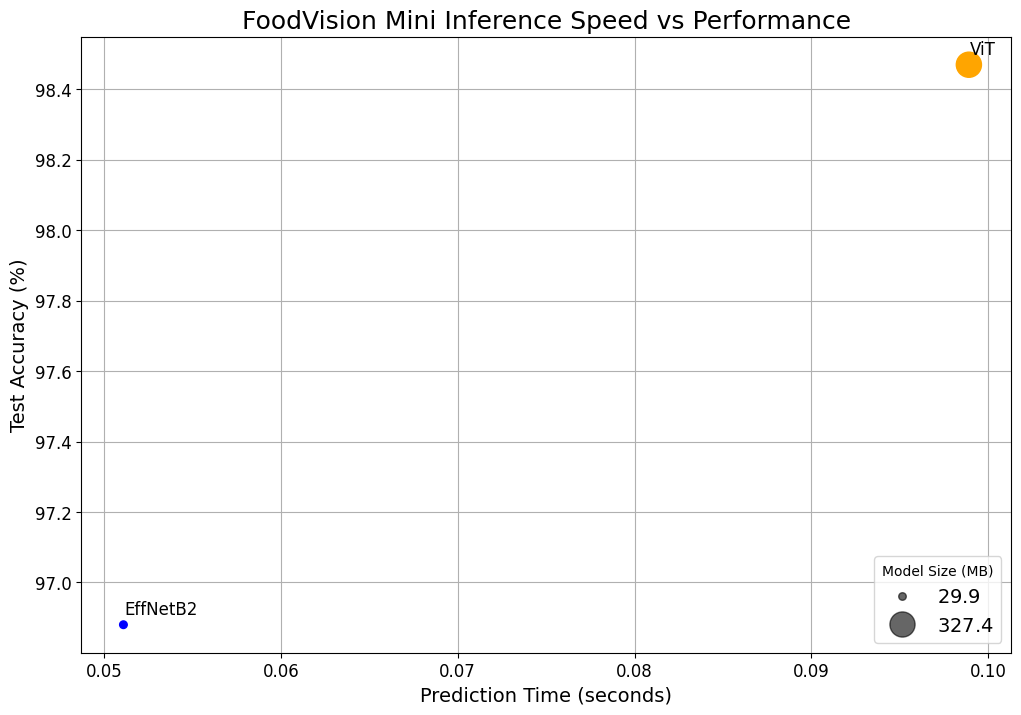

In [ ]:
# 1. Create a plot from model comparison DtaFrame
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (12, 8))
scatter = ax.scatter(data = df,
                     x="time_per_pred",
                     y="test_acc",
                     c = ["blue", "orange"],
                     s = "model_size (MB)")
# 2. Add titles and labels to make our plot look good
ax.set_title("FoodVision Mini Inference Speed vs Performance", fontsize = 18)
ax.set_xlabel("Prediction Time (seconds)", fontsize = 14)
ax.set_ylabel("Test Accuracy (%)", fontsize = 14)
ax.tick_params(axis = "both", labelsize = 12)
ax.grid(True)

# 3. Annotate the samples on the scatter plot so we know what's going on.
for index, row in df.iterrows():
  ax.annotate(text=row["model"],
              xy=(row["time_per_pred"] + 0.00006, row["test_acc"]+0.03),
              size = 12)

# 4. Create a legend based on the model sizes (model_size (MB)).
handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6)
legend = ax.legend(handles,
                   labels,
                   loc = "lower right",
                   title = "Model Size (MB)",
                   fontsize = 14)

# Savev the figure
plt.savefig("09-foodvision-mini-inference-speed-vs-performance.png")

## 7. Bringing FoodVision Mini to life by creating a Gradio demo

We've chosen to deploy EffNetB2 as it fulfills our criteria the best.

What is Gradio?

Gradio is an open-source Python package that allows you to quickly build a demo or web application for your machine learning model, API, or any arbitrary Python function. You can then share a link to your demo or web application in just a few seconds using Gradio's built-in sharing features. No JavaScript, CSS, or web hosting experience needed!

https://www.gradio.app/guides/quickstart

In [ ]:
# Import/install Gradio
try:
    import gradio as gr
except:
    !pip -q install gradio
    import gradio as gr

print(f"Gradio version: {gr.__version__}")

Gradio version: 5.50.0


### 7.1 Gradio overview

Gradio helps you create machine learning demos.

Why create a demo?

So other people can try our models and we can test them in the real-world.

Deployment is as important as training.

Finally, the overall promise of Gradio is to map inputs -> Ml model -> outputs

### 7.2 Creating a function to map our inputs and outputs

In [ ]:
## Put our model on the CPU
effnetb2 = effnetb2.to("cpu")

# Check the device
next(iter(effnetb2.parameters())).device

device(type='cpu')

Let's create a function called `predict()` to go from:

```
images from food -> ML model (EffNetB2) -> outputs (food class label)
```

In [ ]:
from typing import Tuple, Dict

def predict(img) -> Tuple[Dict, float]:
  # Start a timer
  start_time = timer()

  # Transform the input image for use with EffNetB2
  img = effnetb2_transforms(img).unsqueeze(0) # unsqueeze -> add batch dimension on 0th index

  # Put model into eval mode, make prediction
  effnetb2.eval()
  with torch.inference_mode():
    # Pass transformed image through the model and turn the prediction logits into probabilities
    pred_probs = torch.softmax(effnetb2(img), dim = 1)

  # Create a prediction label and prediction probability dictionary
  pred_labels_and_probs = {class_names[i]: float(pred_probs[0][i]) for i in range(len(class_names))}

  # Calculate pred time
  end_time = timer()
  pred_time = round(end_time - start_time, 4)

  # Return pred dict and pred time
  return pred_labels_and_probs, pred_time

In [ ]:
import random
from PIL import Image

# Get a lost of all test image filepaths
test_data_paths = list(Path(test_dir).glob("*//*.jpg"))
print(f"First sample of test data path: {test_data_paths[0]}")

# Randomly select a test image path
random_image_path = random.sample(test_data_paths, k=1)
random_image_path

# Open the target image
image = Image.open(random_image_path[0])
print(f"[INFO] Prediction on image at path: {random_image_path}")

# Predict on the target image and print out the outputs
pred_dict, pred_time = predict(img = image)
pred_dict, pred_time

First sample of test data path: data/pizza_steak_sushi_20_percent/test/sushi/124279.jpg
[INFO] Prediction on image at path: [PosixPath('data/pizza_steak_sushi_20_percent/test/sushi/1404154.jpg')]


({'pizza': 0.0542917363345623,
  'steak': 0.6421682238578796,
  'sushi': 0.30354005098342896},
 0.05)

### 7.3 Creating a list of example images

The examples for Gradio can be created with the `examples` parameter, see here: https://www.gradio.app/main/docs/gradio/interface

In [ ]:
# Create list of example inputs to our Gradio demo
example_list = [[str(filepath)] for filepath in random.sample(test_data_paths, k=3)]
example_list

[['data/pizza_steak_sushi_20_percent/test/pizza/148765.jpg'],
 ['data/pizza_steak_sushi_20_percent/test/steak/1082384.jpg'],
 ['data/pizza_steak_sushi_20_percent/test/steak/1482489.jpg']]

### 7.4 Building a Gradio Interface

Let's use `gr.Interface()` to go from:

```
input: image -> transform -> predict with effnetB2 -> output: pred, prob, time
```

In [ ]:
import gradio

# Create titile, description, and article
title = title = "FoodVision Mini 🍕🥩🍣"
description = "An [EfficientNetB2 feature extractor](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.efficientnet_b2.html#torchvision.models.EfficientNet_B2_Weights) computer vision model to classify images at pizza, steak, or sushi"
article = "Created at [09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/#7-bringing-foodvision-mini-to-life-by-creating-a-gradio-demo)"

# Create the Gradio demo
demo = gr.Interface(fn = predict, #maps inputs to outputs
                    inputs = gr.Image(type = "pil"), # accepts PIL images
                    outputs = [gr.Label(num_top_classes = 3, label = "Predictions"),
                               gr.Number(label = "Prediction time (s)")],
                    examples = example_list,
                    title = title,
                    description = description,
                    article = article)

# Demo launch
demo.launch(debug = False, # print errors locally?
            share = True) # generate a publically shareable URL

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0473c6711ae032ee24.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 8. Turning our FoodVision Mini Gradio Demo into a deployable app

Our Gradio demos from Google Colab are fantastic, but they expire within 72 hours.

To fix this, we're going to prepare our app files so we can host them on Huggingface Spaces: https://huggingface.co/spaces

### 8.1 What is Hugging Face Spaces?
Hugging Face Spaces offer a simple way to host ML demo apps directly on your profile or your organization’s profile. This allows you to create your ML portfolio, showcase your projects at conferences or to stakeholders, and work collaboratively with other people in the ML ecosystem.


Link: https://huggingface.co/docs/hub/spaces

if GitHub is a place to show your coding ability, Hugging Face Spaces is a place to show your machine lerning ability (through sharing ML demos that you've built).

### 8.2 Deployed Gradio app structure

Let's start to pull all of our app files into a single directory:

```
Colab -> folder with all Gradio files ->  uploadd app files to Hugging Face Spaces -> deploy
```

By the end our file structure will look like this

```
demos/
└── foodvision_mini/
    ├── 09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth
    ├── app.py
    ├── examples/
    │   ├── example_1.jpg
    │   ├── example_2.jpg
    │   └── example_3.jpg
    ├── model.py
    └── requirements.txt
```

You can see this in action:
* NOTE OF 04/19/2026... UHMMM none are bneing active, yeaaaah.... so we are gonna follow the educational videos :)

### 8.3 Creating a `demos` folder to store our FoodVision app files

In [ ]:
import shutil
from pathlib import Path

# Create FoodVision mini demo path
foodvision_mini_demo_path = Path("demos/foodvision_mini/")

# Remove that might exist and create a new directory
if foodvision_mini_demo_path.exists():
  shutil.rmtree(foodvision_mini_demo_path)
  foodvision_mini_demo_path.mkdir(parents = True,
                                  exist_ok = True)
else:
  foodvision_mini_demo_path.mkdir(parents = True,
                                  exist_ok = True)

! ls demos/foodvision_mini

### 8.4 Creating a folder of example

What we want:
* 3 images in an `examples/` directory
* Images should be from the test set

In [ ]:
import shutil
from pathlib import Path

# Create an examples directory
foodvision_mini_examples_path = foodvision_mini_demo_path / "examples"
foodvision_mini_examples_path.mkdir(parents = True,
                                     exist_ok = True)

# 2. Collect three random test dataset image paths
foodvision_mini_examples = [Path('data/pizza_steak_sushi_20_percent/test/sushi/592799.jpg'),
                            Path('data/pizza_steak_sushi_20_percent/test/steak/3622237.jpg'),
                            Path('data/pizza_steak_sushi_20_percent/test/pizza/2582289.jpg')]

# Copy the three images to the examples directory
for example in foodvision_mini_examples:
  destination = foodvision_mini_examples_path / example.name
  print(f"[INFO] Copying {example} to {destination}")
  shutil.copy2(src = example,
                dst = destination)


[INFO] Copying data/pizza_steak_sushi_20_percent/test/sushi/592799.jpg to demos/foodvision_mini/examples/592799.jpg
[INFO] Copying data/pizza_steak_sushi_20_percent/test/steak/3622237.jpg to demos/foodvision_mini/examples/3622237.jpg
[INFO] Copying data/pizza_steak_sushi_20_percent/test/pizza/2582289.jpg to demos/foodvision_mini/examples/2582289.jpg


Let's now verify that we can getv a list of lsits from our `examples/` directory

In [ ]:
import os

# Get example filepaths in a list of lists
example_list = [["examples" + os.sep + example] for example in os.listdir(foodvision_mini_examples_path)]
example_list

[['examples/3622237.jpg'], ['examples/592799.jpg'], ['examples/2582289.jpg']]

In [ ]:
foodvision_mini_demo_path

PosixPath('demos/foodvision_mini')

### 8.5 Moving our trained EffNetB2 model to our FoodVision Mini demo directory

In [ ]:
import shutil

# Create a source path for our target model
effnetb2_foodvision_mini_model_path = "models/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth"

# Create a destination path for our target model
effnetb2_foodvision_mini_model_destination= foodvision_mini_demo_path / effnetb2_foodvision_mini_model_path.split("/")[-1]


# Try to move the model file
try:
  print(f"[INFO] Attempting to copy {effnetb2_foodvision_mini_model_path} to {effnetb2_foodvision_mini_model_destination}")

  # Copy the mode
  shutil.copy(src=effnetb2_foodvision_mini_model_path,
              dst = effnetb2_foodvision_mini_model_destination)
  print(f"[INFO] Model copy complete")
except:
  print(f"[INFO]No model found at {effnetb2_foodvision_mini_model_path}, perhapds its already being copied?")
  print(f"[INFO] Model exists at {effnetb2_foodvision_mini_model_destination}: {effnetb2_foodvision_mini_model_destination.exists()}")

[INFO] Attempting to copy models/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth to demos/foodvision_mini/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth
[INFO] Model copy complete


### 8.6 Turning off EffNetB2 model into Python script (`model.py`)

We have a saved `.pth` model `state_dict` and want to load it into a model instance.

let's move our `create_effnetb2_model()` function to a script so we can reuse it.

In [ ]:
%%writefile demos/foodvision_mini/model.py
import torch
import torchvision
from torch import nn

def create_effnetb2_model(num_classes:int = 3, # default output classes =3 (pizza, steak, sushi)
                          seed:int = 42):
  # 1, 2, 3 Create EffNetb2 pretrained weights, transforms, and model
  weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
  transforms = weights.transforms()
  model = torchvision.models.efficientnet_b2(weights=weights)

  # 4. Freeze all layers
  for param in model.parameters():
    param.requires_grad = False

  # 5.Change classifier head with random seed for reproducibility
  torch.manual_seed(seed)
  model.classifier = nn.Sequential(
      nn.Dropout(p = 0.3, inplace=True),
      nn.Linear(in_features=1408, out_features=num_classes)
  )

  return model, transforms

Writing demos/foodvision_mini/model.py


In [ ]:
from demos.foodvision_mini import model

In [ ]:
effnetb2_model, effnetb2_transforms_import = model.create_effnetb2_model()

### 8.7 Turning our FoodVision Mini Gradio app into a Python script (`app.py`)

The `app.py` file will have four major parts:
1. Imports and class names setup
2. Model and transforms preparation
3. Predict function (`predict()`)
4. Gradio app - our Gradio interface + launch command

In [ ]:
%%writefile demos/foodvision_mini/app.py
###
import gradio as gr
import os
import torch

from model import create_effnetb2_model
from timeit import default_timer as timer
from typing import Tuple, Dict

# Setup class names
class_names = ['pizza', 'steak', 'sushi']

### 2. Model and transforms preparation ###
effnetb2, effnetb2_transforms = create_effnetb2_model(
    num_classes=3
)

# Load save weights
effnetb2.load_state_dict(
    torch.load(
        f="09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth",
        map_location=torch.device("cpu") # load the model to the CPU
    )
)

### 3. Predict function ###
def predict(img) -> Tuple[Dict, float]:
  # Start a timer
  start_time = timer()

  # Transform the input image for use with EffNetB2
  img = effnetb2_transforms(img).unsqueeze(0) # unsqueeze -> add batch dimension on 0th index

  # Put model into eval mode, make prediction
  effnetb2.eval()
  with torch.inference_mode():
    # Pass transformed image through the model and turn the prediction logits into probabilities
    pred_probs = torch.softmax(effnetb2(img), dim = 1)

  # Create a prediction label and prediction probability dictionary
  pred_labels_and_probs = {class_names[i]: float(pred_probs[0][i]) for i in range(len(class_names))}

  # Calculate pred time
  end_time = timer()
  pred_time = round(end_time - start_time, 4)

  # Return pred dict and pred time
  return pred_labels_and_probs, pred_time

### 4. Gradio app ###
import gradio

# Create titile, description, and article
title = title = "FoodVision Mini 🍕🥩🍣"
description = "An [EfficientNetB2 feature extractor](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.efficientnet_b2.html#torchvision.models.EfficientNet_B2_Weights) computer vision model to classify images at pizza, steak, or sushi"
article = "Created at [09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/#7-bringing-foodvision-mini-to-life-by-creating-a-gradio-demo)"

# Create examples list
example_list = [["examples" + os.sep + example] for example in os.listdir("examples")]

# Create the Gradio demo
demo = gr.Interface(fn = predict, #maps inputs to outputs
                    inputs = gr.Image(type = "pil"), # accepts PIL images
                    outputs = [gr.Label(num_top_classes = 3, label = "Predictions"),
                               gr.Number(label = "Prediction time (s)")],
                    examples = example_list,
                    title = title,
                    description = description,
                    article = article)

# Demo launch
demo.launch(debug = False, # print errors locally?
            share = True) # generate a publically shareable URL

Writing demos/foodvision_mini/app.py


### 8.8 Creating `requirements.txt`

* torch
* torchvision
* gradio

In [ ]:
%%writefile demos/foodvision_mini/requirements.txt
torch >= 2.2
torchvision >= 0.17
gradio >= 4.0


Writing demos/foodvision_mini/requirements.txt


In [ ]:
torch.__version__

'2.10.0+cu128'

In [ ]:
torchvision.__version__

'0.25.0+cu128'

In [ ]:
gr.__version__

'5.50.0'

## 9. Deploying our FoodVision Mini App

We've got a file containing our FoodVision Mini demo, now how do we get it to run on Hugging Face Spaces?

There are two main options for uploading to a Hugging Face Space (also called a Hugging Face Repository, similar to a git repository):

* Uploading via the Hugging Face Web interface (easiest).
* Uploading via the command line or terminal.
* Bonus: You can also use the huggingface_hub library to interact with Hugging Face, this would be a good extension to the above two options.

### 9,1 Downloading our FoodVision Mini app files

We want to download out `foodvision_mini` demo app so we can upload it to Huggingspaces

In [ ]:
!ls demos/foodvision_mini

09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth
app.py
examples
model.py
__pycache__
requirements.txt


In [ ]:
# Change into the foodvision_mini directory and then zip it from the inside
!cd demos/foodvision_mini && zip -r ../foodvision_mini.zip * -x "*.pyc" "*.ipynb" "*__pycache__*" "*ipynb_checkpoints*"

  adding: 09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth (deflated 8%)
  adding: app.py (deflated 54%)
  adding: examples/ (stored 0%)
  adding: examples/3622237.jpg (deflated 0%)
  adding: examples/592799.jpg (deflated 1%)
  adding: examples/2582289.jpg (deflated 17%)
  adding: model.py (deflated 45%)
  adding: requirements.txt (deflated 11%)


In [ ]:
!pwd

/content


In [ ]:
# Download
try:
  from google.colab import files
  files.download("demos/foodvision_mini.zip")
except:
  print("No running in Google Colab, can't use google.colab.files.download(), please download it manually")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 9.2 Running our Gradio demo app locally

Running the app locally: https://www.learnpytorch.io/09_pytorch_model_deployment/#84-creating-a-folder-of-example-images-to-use-with-our-foodvision-mini-demo

### 9.3 Uploading our FoodVision Mini Gradio demo to Huggingface spaces
Link: https://www.learnpytorch.io/09_pytorch_model_deployment/#93-uploading-to-hugging-face

## 10. Creating FoodVision Big!!
FoodVision Mini Works well with 3 classes (pizza, steak, sushi).

So all of experimenting is paying off...

### 10.1 Creating a model for FoodVision Big + transforms

#

In [ ]:
# Create Food101 models and transforms
effnetb2_food101, effnetb2_transforms = create_effnetb2_model(
    num_classes = 101)

In [ ]:
from torchinfo import summary

# Print EffNetb2 model summary (uncomment for full output)
summary(effnetb2_food101,
        input_size=(1, 3, 224, 224),
        col_names = ["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 101]             --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

Since we're working with a larger dataset, we may want to introduce some data augmentation techniques:
* This is because with larger datasets, and larger models, overfitting becomes more of a problem.
* Because we're working with a large number of classes. Let's use TrivialAugment as our data augmentation technique.

For a list of state-of-the-art computer vision recipes: https://pytorch.org/blog/how-to-train-state-of-the-art-models-using-torchvision-latest-primitives/


In [ ]:
effnetb2_transforms

ImageClassification(
    crop_size=[288]
    resize_size=[288]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [ ]:
# Creating training data transforms
food_101_transforms = torchvision.transforms.Compose([
    torchvision.transforms.TrivialAugmentWide(),
    effnetb2_transforms
])

food_101_transforms

Compose(
    TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
    ImageClassification(
    crop_size=[288]
    resize_size=[288]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)
)

In [ ]:
food_101_transforms

Compose(
    TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
    ImageClassification(
    crop_size=[288]
    resize_size=[288]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)
)

### 10.2 Getting data for FoodVision Big

Get Food101 dataset -https://docs.pytorch.org/vision/main/generated/torchvision.datasets.Food101.html

In [ ]:
from torchvision import datasets

# Setup data directory
from pathlib import Path
data_dir = Path("data")

# Get the training data (~750images x 101 classes)
train_data = datasets.Food101(root=train_dir,
                              split="train",
                              transform = food_101_transforms,
                              download = True)


100%|██████████| 5.00G/5.00G [03:50<00:00, 21.7MB/s]


In [ ]:
# Get the testing data (~250 images x 101 classes)
test_data = datasets.Food101(root = test_dir,
                             split = "test",
                             transform = effnetb2_transforms, # Dont perform data augmentation on the test data
                             download = True)

100%|██████████| 5.00G/5.00G [04:27<00:00, 18.7MB/s]


### 10.3 Creating a subset of FOOd101 dataset for faster experimenting

Why create a subset?

We want our first few experiments to run as quick as possible.

We know FoodVisionMini works pretty well, but this is the first time we've upgraded to 101 classses.

To do so, let's make a subset of 20% of the data from the Food101dataset (training and test).

Our short term goal: We want to beat the original Fod101 paper 56.4% accuracy using CNN. (see the paper: https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/static/bossard_eccv14_food-101.pdf)

We want to beat this result using modern deep lerning techniques and only 20% of the data.

In [ ]:
len(train_data) * 0.2, len(test_data) * 0.2

(15150.0, 5050.0)

In [ ]:
from torch.utils.data import random_split # https://docs.pytorch.org/docs/stable/data.html
def split_dataset(dataset:torchvision.datasets,
              split_size:float = 0.2,
              seed:int = 42):
  #Create split lengths based on the original dataset_length
  length_1 = int(len(dataset) * split_size) # default to 20% data split
  length_2 = len(dataset) - length_1 # remaining length

  #Create splits
  print(f"[INFO] Splitting dataset of length {len(dataset)} into splits of size: {length_1} and {length_2}")

  # Create splits with given random seed
  random_split_1, random_split_2 = torch.utils.data.random_split(dataset,
                                                                 lengths = [length_1, length_2],
                                                                 generator = torch.manual_seed(seed))
  return random_split_1, random_split_2

In [ ]:
# Create training 20% split Food101
train_data_food101_20_percent, _ = split_dataset(dataset = train_data,
                                                 split_size = 0.2)

# Create testing 20% split Food101
test_data_food101_20_percent, _ = split_dataset(dataset = test_data,
                                             split_size = 0.2)

[INFO] Splitting dataset of length 75750 into splits of size: 15150 and 60600
[INFO] Splitting dataset of length 25250 into splits of size: 5050 and 20200


In [ ]:
len(train_data_food101_20_percent), len(test_data_food101_20_percent)

(15150, 5050)

### 10.4 Turning our Food101 datasets into `Dataloaders`

In [ ]:
import os
os.cpu_count()

12

In [ ]:
import torch
import os

NUM_WORKERS = 4 # This number is highly experimental, and th ebest value will differ based on the hardware
BATCH_SIZE = 32

# Create Food101 20% training DataLoader
train_dataloader_food101_20_percent = torch.utils.data.DataLoader(dataset=train_data_food101_20_percent,
                                                                  batch_size=BATCH_SIZE, # GPU memory error is lowering the batch size,
                                                                  shuffle = True,
                                                                  num_workers = NUM_WORKERS,
                                                                  pin_memory = True
                                                                  )

# Create Food101 20% testing DataLoader
test_dataloader_food101_20_percent = torch.utils.data.DataLoader(dataset = test_data_food101_20_percent,
                                                                  batch_size=BATCH_SIZE, # GPU memory error is lowering the batch size,
                                                                  shuffle = True,
                                                                  num_workers = NUM_WORKERS,
                                                                  pin_memory = True
                                                                  )

In [ ]:
len(train_dataloader_food101_20_percent), len(test_dataloader_food101_20_percent)

(474, 158)

### 10.5 Training FoodVision Big!!

Things for training:
* 5 epochs
* Optimizer: `torch.optim.Adam(lr = 1e-3)`
* Loss function: `torch.nn.CrossEntropyLoss(label_smoothing = 0.1)`

Why use label smoothing?

Label smoothing helps to prevetn overfitting (it's a regularization technique).

Without label smoothing and 5 classes:
```
[0.00, 0.00, 0.99, 0.01, 0.00]
```

With label smoothing and 5 classes:

```
[0.01, 0.01, 0.96, 0.01, 0.01]
```

In [ ]:
from going_modular.going_modular import engine

# Setup the optimizer
optimizer = torch.optim.Adam(params = effnetb2_food101.parameters(),
                             lr = 1e-3)

# Setup loss
loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

# Want to beat the 56.1% of CNN of the original Food101 papers on the test dataset with 20% of the data
set_seeds()
effnetb2_food101_results = engine.train(model = effnetb2_food101,
                                        train_dataloader = train_dataloader_food101_20_percent,
                                        test_dataloader = test_dataloader_food101_20_percent,
                                        optimizer = optimizer,
                                        loss_fn = loss_fn,
                                        epochs = 5,
                                        device = device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 2.5375 | train_acc: 0.5462 | test_loss: 2.4687 | test_acc: 0.5304
Epoch: 2 | train_loss: 2.6826 | train_acc: 0.4735 | test_loss: 2.3549 | test_acc: 0.5613
Epoch: 3 | train_loss: 2.5685 | train_acc: 0.5004 | test_loss: 2.3088 | test_acc: 0.5673
Epoch: 4 | train_loss: 2.5014 | train_acc: 0.5214 | test_loss: 2.2851 | test_acc: 0.5718
Epoch: 5 | train_loss: 2.4524 | train_acc: 0.5292 | test_loss: 2.2583 | test_acc: 0.5830


We've just done something in ~4 minutes (5/2/2026), that wasn't possible 12 years ago.

### 10.6 Inspect loss curves of FoodVision Big Model

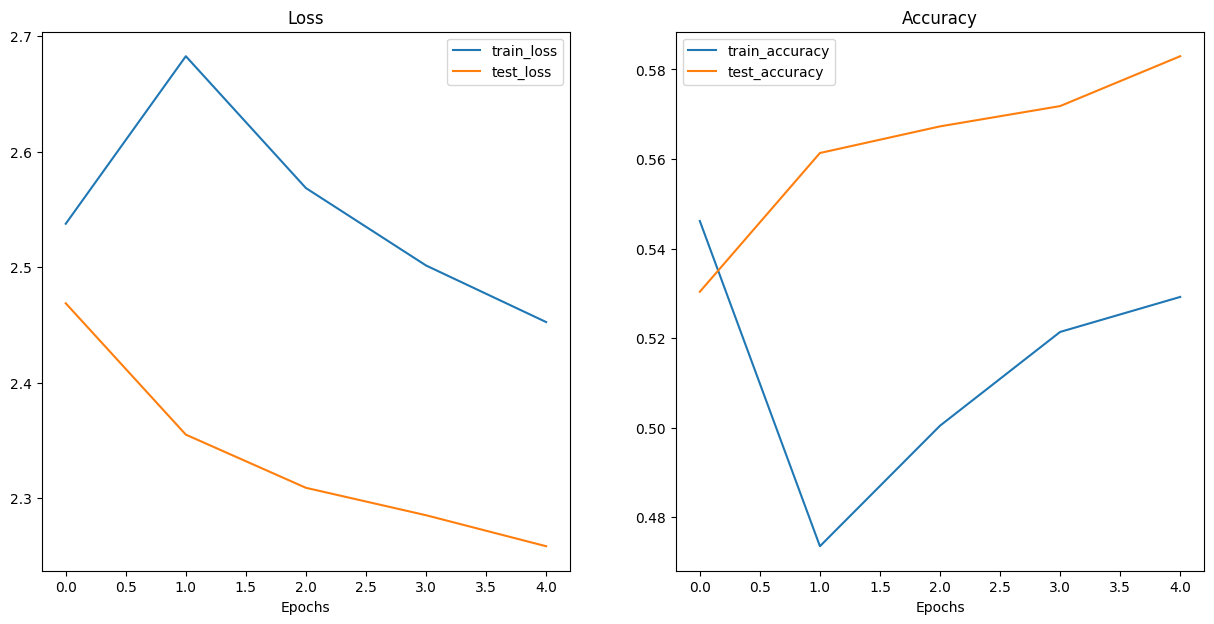

In [ ]:
from helper_functions import plot_loss_curves
plot_loss_curves(effnetb2_food101_results)

### 10.7 Save and loag FoodVision Big model

In [ ]:
from going_modular.going_modular import utils

# Create a model path
effnetb2_food101_model_path = "09_pretained_effnetb2_feature_extractor_food101_20_percent.pth"

# Save the FoodVision Big model
utils.save_model(model = effnetb2_food101,
                 target_dir = "models/",
                 model_name = effnetb2_food101_model_path)

[INFO] Saving model to: models/09_pretained_effnetb2_feature_extractor_food101_20_percent.pth


In [ ]:
# Create Food101 compatible EffNetb2 instance
loaded_effnetb2_food101, effnetb2_transforms = create_effnetb2_model(num_classes = 101)

# Load the saved model's state dict
loaded_effnetb2_food101.load_state_dict(torch.load(f = "models/09_pretained_effnetb2_feature_extractor_food101_20_percent.pth"))

<All keys matched successfully>

### 10.8 Checking FoodVision Big model size

In [ ]:
from pathlib import Path

# Get the model size in bytes then convert to megabytes
pretrained_effnetb2_food101_model_size = Path("models", effnetb2_food101_model_path).stat().st_size / (1024 * 1024)
print(f"Pretrained EffNetB2 feature extractor Food101 model suze: {pretrained_effnetb2_food101_model_size} MB")

Pretrained EffNetB2 feature extractor Food101 model suze: 30.38145160675049 MB


In [ ]:
from torchinfo import summary

# Print EffNetB2 model summary for FoodVision  101
summary(model  = loaded_effnetb2_food101,
        input_size = (1, 3, 224, 224),
        col_width = 20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Output Shape         Param #
EfficientNet (EfficientNet)                                  [1, 101]             --
├─Sequential (features)                                      [1, 1408, 7, 7]      --
│    └─Conv2dNormActivation (0)                              [1, 32, 112, 112]    --
│    │    └─Conv2d (0)                                       [1, 32, 112, 112]    (864)
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    (64)
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    --
│    └─Sequential (1)                                        [1, 16, 112, 112]    --
│    │    └─MBConv (0)                                       [1, 16, 112, 112]    (1,448)
│    │    └─MBConv (1)                                       [1, 16, 112, 112]    (612)
│    └─Sequential (2)                                        [1, 24, 56, 56]      --
│    │    └─MBConv (0)                         

## 11. Turning our FoodVision Big model into a deployable app

Why deploy a model?

Deploying a model allows you to see how your model goes in the real-world (the ultimate test set).

Let's create an outline for our FoodVision Big App:
```
demos/
  foodvision_big/
    09_pretrained_effnetb2_feature_extractor_food101_20_percent.pth
    app.py
    class_names.txt
    examples/
      example_1.jpg
    model.py
    requirements.txt
```

In [ ]:
from pathlib import Path

# Create FoodVision Big demo path
foodvision_big_demo_path = Path("demos", "foodvision_big")

# Make FoodVision Big demo directory
foodvision_big_demo_path.mkdir(parents = True, exist_ok = True)

# Make foodVision Big demo examples directory
(foodvision_big_demo_path / "examples").mkdir(parents = True, exist_ok = True)

In [ ]:
!ls demos/foodvision_big/

examples


### 11.1 Downloading an example image and moving it to the `examples` directory

In [ ]:
food101_class_names = train_data.classes

In [ ]:
# Download and move example image
!wget https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/data/04-pizza-dad.jpeg
!mv 04-pizza-dad.jpeg demos/foodvision_big/examples/04-pizza-dad.jpeg

--2026-05-02 19:07:26--  https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/data/04-pizza-dad.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2874848 (2.7M) [image/jpeg]
Saving to: ‘04-pizza-dad.jpeg’

04-pizza-dad.jpeg   100%[===================>]   2.74M  --.-KB/s    in 0.009s  

2026-05-02 19:07:26 (296 MB/s) - ‘04-pizza-dad.jpeg’ saved [2874848/2874848]



In [ ]:
!mv models/09_pretained_effnetb2_feature_extractor_food101_20_percent.pth demos/foodvision_big/

### 11.2 Saving Food101 class names to file (`class_names.txt`)
Let's save all of the Food101 class names to `.txt` file so we can import them and use them in our app.

In [ ]:
# Check out the first 10 Food101 class names
food101_class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [ ]:
# Create a path to Food101 class names
foodvision_big_class_names_path = foodvision_big_demo_path / "class_names.txt"
foodvision_big_class_names_path

PosixPath('demos/foodvision_big/class_names.txt')

In [ ]:
# Write Food101 class names to text file
with open(foodvision_big_class_names_path, "w") as f:
  print(f"[INFO] Saving Food101 class names to {foodvision_big_class_names_path}")
  f.write(f"\n".join(food101_class_names))

[INFO] Saving Food101 class names to demos/foodvision_big/class_names.txt


In [ ]:
# Open Food101 class names file and read each line into a list
with open(foodvision_big_class_names_path, "r") as f:
  print(f"[INFO] Reading Food101 class names from {foodvision_big_class_names_path}")
  food101_class_names_loaded = [food.strip() for food in f.readlines()]
food101_class_names_loaded[:5]

[INFO] Reading Food101 class names from demos/foodvision_big/class_names.txt


['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare']

### 11.3 Turning our FoodVision Big model into a python script (`model.py`)

In [ ]:
%%writefile demos/foodvision_big/model.py
import torch
import torchvision
from torch import nn

def create_effnetb2_model(num_classes:int = 101, # default output classes = 101 class for Foodvision Big
                          seed:int = 42):
  # 1, 2, 3 Create EffNetb2 pretrained weights, transforms, and model
  weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
  transforms = weights.transforms()
  model = torchvision.models.efficientnet_b2(weights=weights)

  # 4. Freeze all layers
  for param in model.parameters():
    param.requires_grad = False

  # 5.Change classifier head with random seed for reproducibility
  torch.manual_seed(seed)
  model.classifier = nn.Sequential(
      nn.Dropout(p = 0.3, inplace=True),
      nn.Linear(in_features=1408, out_features=num_classes)
  )

  return model, transforms

Writing demos/foodvision_big/model.py


### 11.4 Turning our FoodVision Big Gradio App into a python script (`app.py`)

The `app.py` file will have four major parts:
1. Imports and class names setup - for class names, we'll need to import from `class_names.txt` rather than a python list.
2. Model and transforms preparation - we'll need to make sure our model is suitable for FoodVision Big
3. Predict function (`predict()`) - this cans stay the same as the original `predict()`.
4. Gradio app - our Gradio interfece + launch command - this will slightly from FoodVision Mini to reflect FoodVision Big.

In [ ]:
%%writefile demos/foodvision_big/app.py
### 1. Import and class names setup ###
import gradio as gr
import os
import torch

from model import create_effnetb2_model
from timeit import default_timer as timer
from typing import Tuple, Dict

# Setup class names
with open("class_names.txt", 'r') as f:
  class_names = [food_name.strip() for food_name in f.readlines()]

### 2. Model and transforms preparation ###
# Create model and transforms
effnetb2, effnetb2_transforms = create_effnetb2_model(num_classes=101)

# Load the saved weights
effnetb2.load_state_dict(torch.load(f = "09_pretained_effnetb2_feature_extractor_food101_20_percent.pth"),
                         map_location = torch.device("cpu") # Loaded mapping into cpu so huggingface cpu server can be used without errors
                         )

### 3. Predict function ###
def predict(img) -> Tuple[Dict, float]:
  # Start a timer
  start_time = timer()

  # Transform the input image for use with EffNetB2
  img = effnetb2_transforms(img).unsqueeze(0) # unsqueeze -> add batch dimension on 0th index

  # Put model into eval mode, make prediction
  effnetb2.eval()
  with torch.inference_mode():
    # Pass transformed image through the model and turn the prediction logits into probabilities
    pred_probs = torch.softmax(effnetb2(img), dim = 1)

  # Create a prediction label and prediction probability dictionary
  pred_labels_and_probs = {class_names[i]: float(pred_probs[0][i]) for i in range(len(class_names))}

  # Calculate pred time
  end_time = timer()
  pred_time = round(end_time - start_time, 4)

  # Return pred dict and pred time
  return pred_labels_and_probs, pred_time

### 4. Gradio app ###
# Create titile, description, and article
title = title = "FoodVision BIG 👁️🍔💪"
description = "An [EfficientNetB2 feature extractor](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.efficientnet_b2.html#torchvision.models.EfficientNet_B2_Weights) computer vision model to classify [101 classes of food from the Food101 dataset](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/food101_class_names.txt)."
article = "Created at [09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/#11-turning-our-foodvision-big-model-into-a-deployable-app)"

# Create examples list
example_list = [["examples" + os.sep + example] for example in os.listdir("examples")]

# Create the Gradio demo
demo = gr.Interface(fn = predict, #maps inputs to outputs
                    inputs = gr.Image(type = "pil"), # accepts PIL images
                    outputs = [gr.Label(num_top_classes = 5, label = "Predictions"),
                               gr.Number(label = "Prediction time (s)")],
                    examples = example_list,
                    title = title,
                    description = description,
                    article = article)

# Demo launch
demo.launch()

Writing demos/foodvision_big/app.py


### 11.5 Creating a `requirements.txt` file for FoodVision101 Big

In [ ]:
%%writefile demos/foodvision_big/requirements.txt
torch >= 2.2
torchvision >= 0.17
gradio >= 4.0

Writing demos/foodvision_big/requirements.txt


### 11.6 Downloading our FoodVision Big app files

In [ ]:
# Change into the foodvision_mini directory and then zip it from the inside
!cd demos/foodvision_big && zip -r ../foodvision_big.zip * -x "*.pyc" "*.ipynb" "*__pycache__*" "*ipynb_checkpoints*"

  adding: 09_pretained_effnetb2_feature_extractor_food101_20_percent.pth (deflated 8%)
  adding: app.py (deflated 54%)
  adding: class_names.txt (deflated 48%)
  adding: examples/ (stored 0%)
  adding: examples/3622237.jpg (deflated 0%)
  adding: examples/04-pizza-dad.jpeg (deflated 0%)
  adding: examples/592799.jpg (deflated 1%)
  adding: examples/2582289.jpg (deflated 17%)
  adding: model.py (deflated 46%)
  adding: requirements.txt (deflated 11%)


In [ ]:
# Download
try:
  from google.colab import files
  files.download("demos/foodvision_big.zip")
except:
  print("No running in Google Colab, can't use google.colab.files.download(), please download it manually")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>